# Данный ноутбук также расчитывает оптимальные пороги отсечения для каждого класса.

# перерасчет логитов на тренировочной и валидационной выборке

In [89]:
import numpy as np

# Загружаем логиты DenseNet-121
logits_data = np.load('densenet121_logits.npz')

# Записываем в переменные
train_logits_dn121 = logits_data['train_logits']
train_indices_dn121 = logits_data['train_indices']
val_logits_dn121 = logits_data['val_logits']
val_indices_dn121 = logits_data['val_indices']

print("✅ Логиты загружены в переменные")
print(f"   train_logits_dn121: {train_logits_dn121.shape}")
print(f"   val_logits_dn121: {val_logits_dn121.shape}")

✅ Логиты загружены в переменные
   train_logits_dn121: (78481, 15)
   val_logits_dn121: (16821, 15)


In [90]:
train_logits_dn121.shape

(78481, 15)

In [91]:
import numpy as np

# Загружаем логиты EfficientNet
effnet_data = np.load('efficientnet_logits.npz')

# Записываем в переменные
train_logits_effnet = effnet_data['train_logits']
train_indices_effnet = effnet_data['train_indices']
train_labels_effnet = effnet_data['train_labels']

val_logits_effnet = effnet_data['val_logits']
val_indices_effnet = effnet_data['val_indices']
val_labels_effnet = effnet_data['val_labels']

print("✅ Логиты EfficientNet загружены")
print(f"Train: {train_logits_effnet.shape}")
print(f"Val: {val_logits_effnet.shape}")

✅ Логиты EfficientNet загружены
Train: (78481, 15)
Val: (16821, 15)


In [92]:
import numpy as np

# Загружаем логиты Swin-Tiny
swin_data = np.load('swin_logits.npz')

# Записываем в переменные
train_logits_swin = swin_data['train_logits']
train_indices_swin = swin_data['train_indices']
train_labels_swin = swin_data['train_labels']

val_logits_swin = swin_data['val_logits']
val_indices_swin = swin_data['val_indices']
val_labels_swin = swin_data['val_labels']

print(" Логиты Swin-Tiny загружены")
print(f"Train: {train_logits_swin.shape}")
print(f"Val: {val_logits_swin.shape}")

 Логиты Swin-Tiny загружены
Train: (78481, 15)
Val: (16821, 15)


# обьединяем все логиты

In [93]:
train_log = np.concatenate([train_logits_dn121, train_logits_effnet, train_logits_swin], axis = 1)

In [94]:
train_log.shape

(78481, 45)

In [95]:
val_log = np.concatenate([val_logits_dn121, val_logits_effnet, val_logits_swin], axis = 1)

In [96]:
val_log.shape

(16821, 45)

In [97]:
full_ligits = np.concatenate([train_log, val_log], axis = 0)

In [98]:
full_ligits.shape

(95302, 45)

# обьединяем все целевые значения

In [99]:
train_labels_effnet.shape

(78481, 15)

In [100]:
val_labels_effnet.shape

(16821, 15)

In [101]:
full_lables = np.concatenate([train_labels_effnet, val_labels_effnet], axis = 0)

In [102]:
full_lables.shape

(95302, 15)

# Прогоняем логиты через мета модель

In [103]:
from meta_model import load_meta_model

predictor = load_meta_model('full_meta_model.pth')

In [104]:
ansver_meta_model = predictor.predict(full_ligits)

In [105]:
ansver_meta_model

{'probabilities': array([[0.03121532, 0.00075909, 0.00910381, ..., 0.02640085, 0.00585916,
         0.01005709],
        [0.00671714, 0.00081725, 0.00243304, ..., 0.00274197, 0.00330129,
         0.00046556],
        [0.16618793, 0.00895447, 0.03907192, ..., 0.08224235, 0.00266746,
         0.44672436],
        ...,
        [0.20436518, 0.03612632, 0.1432616 , ..., 0.0390999 , 0.05452376,
         0.00473695],
        [0.00695716, 0.0032807 , 0.00319157, ..., 0.00830542, 0.00278228,
         0.00055884],
        [0.10356236, 0.00861942, 0.0300908 , ..., 0.00144282, 0.00797448,
         0.00318935]], dtype=float32),
 'binary_predictions': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 1.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 'diseases': ['Atelectasis',
  'Cardiomegaly',
  'Consolidation',
  'Edema',
  'Effusion',


In [106]:
probabilities = ansver_meta_model['probabilities']

In [107]:
probabilities[0]

array([3.1215319e-02, 7.5909460e-04, 9.1038113e-03, 5.1402900e-04,
       9.5038535e-03, 1.7964922e-02, 2.8159028e-02, 3.6936423e-03,
       1.2883116e-01, 1.7180942e-02, 7.1414995e-01, 4.6945810e-02,
       2.6400853e-02, 5.8591552e-03, 1.0057087e-02], dtype=float32)

In [108]:
full_lables[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
      dtype=float32)

переминование переменных

In [109]:
all_probabilities = probabilities
all_true_labels = full_lables
diseases_list = ansver_meta_model['diseases']

In [112]:
all_probabilities.shape

(95302, 15)

# подбор порога отсечения

In [113]:
# ЯЧЕЙКА 1: Подготовка данных и базовые функции
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

print("🎯 ПОДБОР ПОРОГОВ ДЛЯ КАЖДОГО КЛАССА")
print("=" * 60)

# Базовые функции для подбора порогов
def find_threshold_by_f1(probabilities, true_labels):
    """Находит порог, максимизирующий F1-score"""
    thresholds = np.linspace(0.01, 0.99, 100)
    best_f1 = 0
    best_threshold = 0.5
    
    for thresh in thresholds:
        preds = (probabilities > thresh).astype(int)
        f1 = f1_score(true_labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh
    
    return best_threshold, best_f1

def find_threshold_by_youden(probabilities, true_labels):
    """Находит порог по критерию Юдена (J = sens + spec - 1)"""
    fpr, tpr, thresholds = roc_curve(true_labels, probabilities)
    youden_idx = np.argmax(tpr - fpr)
    return thresholds[youden_idx], tpr[youden_idx] - fpr[youden_idx]

def find_threshold_for_recall(probabilities, true_labels, target_recall=0.8):
    """Находит порог для достижения целевого recall"""
    thresholds = np.linspace(0.01, 0.99, 200)
    
    for thresh in thresholds[::-1]:  # Идем от высоких к низким
        preds = (probabilities > thresh).astype(int)
        rec = recall_score(true_labels, preds, zero_division=0)
        if rec >= target_recall:
            prec = precision_score(true_labels, preds, zero_division=0)
            f1 = f1_score(true_labels, preds, zero_division=0)
            return thresh, rec, prec, f1
    
    return 0.01, recall_score(true_labels, (probabilities > 0.01).astype(int), zero_division=0), 0, 0

🎯 ПОДБОР ПОРОГОВ ДЛЯ КАЖДОГО КЛАССА


In [114]:
# ЯЧЕЙКА 2: Подбор порогов разными методами
print("\n🔍 ПОДБОР ПОРОГОВ РАЗНЫМИ МЕТОДАМИ")
print("=" * 60)

thresholds_f1 = {}
thresholds_youden = {}
thresholds_recall80 = {}
thresholds_recall50 = {}

for i, disease in enumerate(diseases_list):
    if np.sum(all_true_labels[:, i]) > 0:
        probs = all_probabilities[:, i]
        labels = all_true_labels[:, i]
        
        # Метод 1: Оптимизация по F1
        thresh_f1, f1_val = find_threshold_by_f1(probs, labels)
        thresholds_f1[disease] = thresh_f1
        
        # Метод 2: Критерий Юдена
        thresh_y, youden_val = find_threshold_by_youden(probs, labels)
        thresholds_youden[disease] = thresh_y
        
        # Метод 3: Recall 80%
        thresh_r80, rec80, prec80, f1_80 = find_threshold_for_recall(probs, labels, target_recall=0.8)
        thresholds_recall80[disease] = thresh_r80
        
        # Метод 4: Recall 50%
        thresh_r50, rec50, prec50, f1_50 = find_threshold_for_recall(probs, labels, target_recall=0.5)
        thresholds_recall50[disease] = thresh_r50
        
        # Вывод
        print(f"\n{disease:20s}:")
        print(f"  F1-opt:    порог={thresh_f1:.3f}, F1={f1_val:.3f}")
        print(f"  Youden:    порог={thresh_y:.3f}, J={youden_val:.3f}")
        print(f"  Recall80%: порог={thresh_r80:.3f}, rec={rec80:.3f}, prec={prec80:.3f}, F1={f1_80:.3f}")
        print(f"  Recall50%: порог={thresh_r50:.3f}, rec={rec50:.3f}, prec={prec50:.3f}, F1={f1_50:.3f}")


🔍 ПОДБОР ПОРОГОВ РАЗНЫМИ МЕТОДАМИ

Atelectasis         :
  F1-opt:    порог=0.218, F1=0.437
  Youden:    порог=0.109, J=0.531
  Recall80%: порог=0.108, rec=0.807, prec=0.251, F1=0.383
  Recall50%: порог=0.237, rec=0.507, prec=0.379, F1=0.434

Cardiomegaly        :
  F1-opt:    порог=0.208, F1=0.369
  Youden:    порог=0.040, J=0.664
  Recall80%: порог=0.049, rec=0.819, prec=0.114, F1=0.200
  Recall50%: порог=0.163, rec=0.502, prec=0.274, F1=0.354

Consolidation       :
  F1-opt:    порог=0.129, F1=0.242
  Youden:    порог=0.046, J=0.504
  Recall80%: порог=0.044, rec=0.811, prec=0.102, F1=0.181
  Recall50%: порог=0.108, rec=0.518, prec=0.151, F1=0.234

Edema               :
  F1-opt:    порог=0.139, F1=0.279
  Youden:    порог=0.022, J=0.688
  Recall80%: порог=0.040, rec=0.811, prec=0.105, F1=0.186
  Recall50%: порог=0.113, rec=0.511, prec=0.184, F1=0.270

Effusion            :
  F1-opt:    порог=0.297, F1=0.568
  Youden:    порог=0.132, J=0.645
  Recall80%: порог=0.158, rec=0.802, prec


📈 ВИЗУАЛИЗАЦИЯ PRECISION-RECALL КРИВЫХ


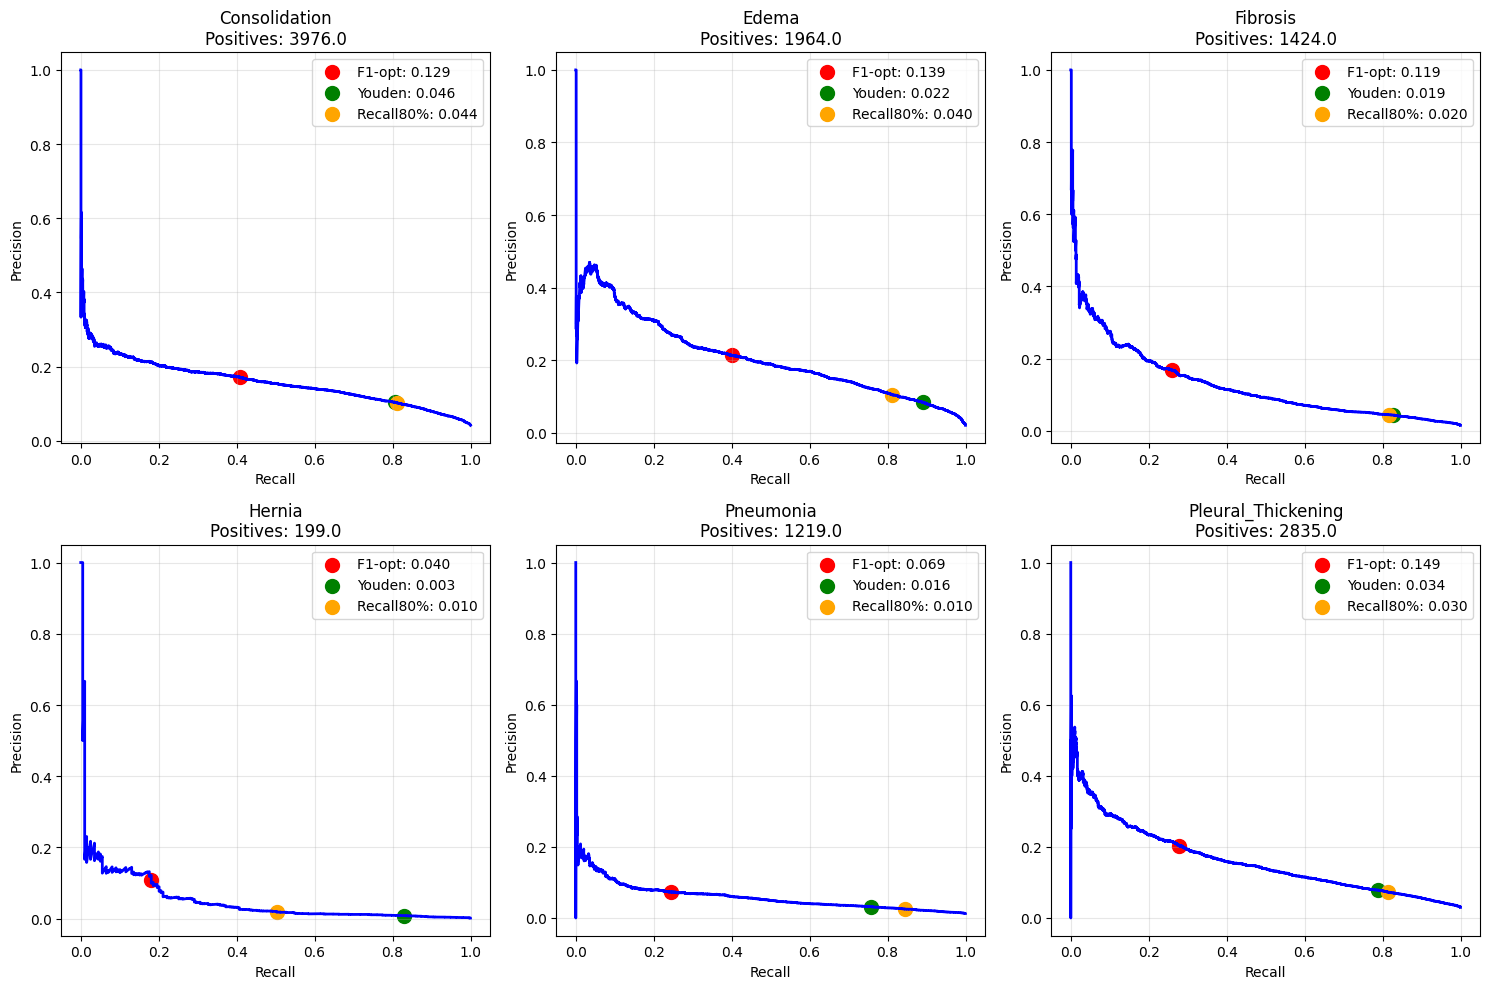

In [115]:
# ЯЧЕЙКА 3: Визуализация Precision-Recall кривых
print("\n📈 ВИЗУАЛИЗАЦИЯ PRECISION-RECALL КРИВЫХ")
print("=" * 60)

# Создаем графики для 6 проблемных классов
problem_classes = ['Consolidation', 'Edema', 'Fibrosis', 'Hernia', 'Pneumonia', 'Pleural_Thickening']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, disease in enumerate(problem_classes):
    if disease in diseases_list:
        i = diseases_list.index(disease)
        probs = all_probabilities[:, i]
        labels = all_true_labels[:, i]
        
        if np.sum(labels) > 0:
            precision, recall, thresholds_pr = precision_recall_curve(labels, probs)
            
            axes[idx].plot(recall, precision, 'b-', linewidth=2)
            axes[idx].set_xlabel('Recall')
            axes[idx].set_ylabel('Precision')
            axes[idx].set_title(f'{disease}\nPositives: {np.sum(labels)}')
            axes[idx].grid(True, alpha=0.3)
            
            # Отмечаем разные пороги
            for method, thresh, color in [
                ('F1-opt', thresholds_f1.get(disease, 0.5), 'red'),
                ('Youden', thresholds_youden.get(disease, 0.5), 'green'),
                ('Recall80%', thresholds_recall80.get(disease, 0.5), 'orange')
            ]:
                if thresh < 1.0:  # Избегаем крайних значений
                    preds = (probs > thresh).astype(int)
                    p = precision_score(labels, preds, zero_division=0)
                    r = recall_score(labels, preds, zero_division=0)
                    axes[idx].scatter(r, p, color=color, s=100, label=f'{method}: {thresh:.3f}')
            
            axes[idx].legend(loc='best')

plt.tight_layout()
plt.show()

In [116]:
# ЯЧЕЙКА 4: Анализ распределения вероятностей для проблемных классов
print("\n📊 РАСПРЕДЕЛЕНИЕ ВЕРОЯТНОСТЕЙ ДЛЯ ПРОБЛЕМНЫХ КЛАССОВ")
print("=" * 60)

for disease in ['Consolidation', 'Edema', 'Fibrosis', 'Hernia', 'Pneumonia']:
    if disease in diseases_list:
        i = diseases_list.index(disease)
        probs = all_probabilities[:, i]
        labels = all_true_labels[:, i]
        
        if np.sum(labels) > 0:
            print(f"\n{disease}:")
            print(f"  Всего образцов: {len(probs)}")
            print(f"  Положительных: {np.sum(labels)} ({np.sum(labels)/len(probs)*100:.1f}%)")
            
            # Для положительных случаев
            pos_probs = probs[labels == 1]
            print(f"  Вероятности для положительных:")
            print(f"    Min: {pos_probs.min():.3f}")
            print(f"    Max: {pos_probs.max():.3f}")
            print(f"    Mean: {pos_probs.mean():.3f}")
            print(f"    Median: {np.median(pos_probs):.3f}")
            print(f"    90% квантиль: {np.quantile(pos_probs, 0.9):.3f}")
            
            # Сколько выше порога 0.5
            above_05 = (pos_probs > 0.5).sum()
            print(f"    Выше 0.5: {above_05}/{len(pos_probs)} ({above_05/len(pos_probs)*100:.1f}%)")
            
            # Предлагаемый порог на основе квантиля
            suggested_thresh = np.quantile(pos_probs, 0.1)  # Нижний 10% квантиль
            print(f"  Предлагаемый порог (10% квантиль): {suggested_thresh:.3f}")


📊 РАСПРЕДЕЛЕНИЕ ВЕРОЯТНОСТЕЙ ДЛЯ ПРОБЛЕМНЫХ КЛАССОВ

Consolidation:
  Всего образцов: 95302
  Положительных: 3976.0 (4.2%)
  Вероятности для положительных:
    Min: 0.001
    Max: 0.663
    Mean: 0.110
    Median: 0.112
    90% квантиль: 0.187
    Выше 0.5: 2/3976 (0.1%)
  Предлагаемый порог (10% квантиль): 0.023

Edema:
  Всего образцов: 95302
  Положительных: 1964.0 (2.1%)
  Вероятности для положительных:
    Min: 0.000
    Max: 0.476
    Mean: 0.122
    Median: 0.117
    90% квантиль: 0.226
    Выше 0.5: 0/1964 (0.0%)
  Предлагаемый порог (10% квантиль): 0.020

Fibrosis:
  Всего образцов: 95302
  Положительных: 1424.0 (1.5%)
  Вероятности для положительных:
    Min: 0.001
    Max: 0.620
    Mean: 0.093
    Median: 0.058
    90% квантиль: 0.233
    Выше 0.5: 8/1424 (0.6%)
  Предлагаемый порог (10% квантиль): 0.011

Hernia:
  Всего образцов: 95302
  Положительных: 199.0 (0.2%)
  Вероятности для положительных:
    Min: 0.000
    Max: 0.298
    Mean: 0.021
    Median: 0.010
    90% ква

In [117]:
# ЯЧЕЙКА 5: Практические рекомендации по порогам
print("\n🎯 ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ ПО ПОРОГАМ")
print("=" * 60)

# Агрегируем рекомендации из разных методов
final_thresholds = {}

for disease in diseases_list:
    if disease in thresholds_f1:
        # Для редких классов используем Recall-based подход
        class_freq = np.sum(all_true_labels[:, diseases_list.index(disease)]) / len(all_true_labels)
        
        if class_freq < 0.01:  # Очень редкие (<1%)
            # Берём минимум из Recall50% и 10% квантиля
            i = diseases_list.index(disease)
            pos_probs = all_probabilities[all_true_labels[:, i] == 1, i]
            if len(pos_probs) > 0:
                quantile_10 = np.quantile(pos_probs, 0.1)
                final_thresh = min(thresholds_recall50.get(disease, 0.5), quantile_10)
                final_thresh = max(0.05, min(0.3, final_thresh))  # Ограничиваем 0.05-0.3
            else:
                final_thresh = 0.1
        
        elif class_freq < 0.05:  # Редкие (1-5%)
            # Среднее между F1-opt и Recall50%
            thresh_f1 = thresholds_f1.get(disease, 0.5)
            thresh_r50 = thresholds_recall50.get(disease, 0.5)
            final_thresh = (thresh_f1 + thresh_r50) / 2
            final_thresh = max(0.1, min(0.4, final_thresh))
        
        else:  # Частые (>5%)
            # Используем F1-opt, но не ниже 0.3
            final_thresh = max(0.3, thresholds_f1.get(disease, 0.5))
        
        final_thresholds[disease] = final_thresh

# Выводим финальные пороги
print("\nРекомендованные пороги:")
print("-" * 50)
for disease, thresh in final_thresholds.items():
    i = diseases_list.index(disease)
    class_freq = np.sum(all_true_labels[:, i]) / len(all_true_labels)
    print(f"{disease:20s}: порог={thresh:.3f} (частота: {class_freq:.3%})")


🎯 ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ ПО ПОРОГАМ

Рекомендованные пороги:
--------------------------------------------------
Atelectasis         : порог=0.300 (частота: 10.320%)
Cardiomegaly        : порог=0.185 (частота: 2.485%)
Consolidation       : порог=0.119 (частота: 4.172%)
Edema               : порог=0.126 (частота: 2.061%)
Effusion            : порог=0.300 (частота: 11.873%)
Emphysema           : порог=0.346 (частота: 2.256%)
Fibrosis            : порог=0.100 (частота: 1.494%)
Hernia              : порог=0.050 (частота: 0.209%)
Infiltration        : порог=0.300 (частота: 17.754%)
Mass                : порог=0.300 (частота: 5.166%)
No Finding          : порог=0.386 (частота: 53.836%)
Nodule              : порог=0.300 (частота: 5.627%)
Pleural_Thickening  : порог=0.116 (частота: 2.975%)
Pneumonia           : порог=0.100 (частота: 1.279%)
Pneumothorax        : порог=0.264 (частота: 4.746%)


In [118]:
# ЯЧЕЙКА 6: Тестирование рекомендованных порогов
print("\n🧪 ТЕСТИРОВАНИЕ РЕКОМЕНДОВАННЫХ ПОРОГОВ")
print("=" * 60)

# Функция для оценки с кастомными порогами
def evaluate_with_thresholds(probabilities, true_labels, thresholds_dict):
    predictions = np.zeros_like(probabilities)
    
    for i, disease in enumerate(diseases_list):
        threshold = thresholds_dict.get(disease, 0.5)
        predictions[:, i] = (probabilities[:, i] > threshold).astype(float)
    
    return predictions

# Применяем рекомендованные пороги
custom_predictions = evaluate_with_thresholds(all_probabilities, all_true_labels, final_thresholds)

# Сравниваем метрики
print("\nСРАВНЕНИЕ МЕТРИК:")
print("-" * 50)
print(f"{'Класс':20s} {'Порог':10s} {'Recall (старый)':15s} {'Recall (новый)':15s} {'F1 (старый)':12s} {'F1 (новый)':12s}")
print("-" * 80)

for disease in diseases_list:
    i = diseases_list.index(disease)
    if np.sum(all_true_labels[:, i]) > 0:
        # Старые метрики (порог 0.5)
        old_preds = (all_probabilities[:, i] > 0.5).astype(int)
        old_recall = recall_score(all_true_labels[:, i], old_preds, zero_division=0)
        old_f1 = f1_score(all_true_labels[:, i], old_preds, zero_division=0)
        
        # Новые метрики
        new_preds = custom_predictions[:, i].astype(int)
        new_recall = recall_score(all_true_labels[:, i], new_preds, zero_division=0)
        new_f1 = f1_score(all_true_labels[:, i], new_preds, zero_division=0)
        
        print(f"{disease:20s} {final_thresholds.get(disease, 0.5):10.3f} "
              f"{old_recall:15.3f} {new_recall:15.3f} "
              f"{old_f1:12.3f} {new_f1:12.3f}")


🧪 ТЕСТИРОВАНИЕ РЕКОМЕНДОВАННЫХ ПОРОГОВ

СРАВНЕНИЕ МЕТРИК:
--------------------------------------------------
Класс                Порог      Recall (старый) Recall (новый)  F1 (старый)  F1 (новый)  
--------------------------------------------------------------------------------
Atelectasis               0.300           0.087           0.374        0.152        0.405
Cardiomegaly              0.185           0.100           0.451        0.172        0.360
Consolidation             0.119           0.001           0.461        0.001        0.237
Edema                     0.126           0.000           0.457        0.000        0.276
Effusion                  0.300           0.317           0.615        0.433        0.568
Emphysema                 0.346           0.331           0.546        0.422        0.522
Fibrosis                  0.100           0.006           0.312        0.011        0.196
Hernia                    0.050           0.000           0.116        0.000        0.124

In [119]:
# ЯЧЕЙКА 7: Итоговые пороги для использования
print("\n🎯 ИТОГОВЫЕ ПОРОГИ ДЛЯ ИСПОЛЬЗОВАНИЯ")
print("=" * 60)

# Округляем до разумных значений
final_thresholds_rounded = {}
for disease, thresh in final_thresholds.items():
    # Округляем до 0.05
    rounded = round(thresh / 0.05) * 0.05
    final_thresholds_rounded[disease] = max(0.05, min(0.95, rounded))

print("\nОкругленные пороги:")
print("-" * 50)
for disease, thresh in final_thresholds_rounded.items():
    print(f"    '{disease}': {thresh:.2f},")

# Сохраняем пороги в файл
#import json
#with open('optimal_thresholds.json', 'w') as f:
#    json.dump(final_thresholds_rounded, f, indent=2)

#print(f"\n💾 Пороги сохранены в 'optimal_thresholds.json'")


🎯 ИТОГОВЫЕ ПОРОГИ ДЛЯ ИСПОЛЬЗОВАНИЯ

Округленные пороги:
--------------------------------------------------
    'Atelectasis': 0.30,
    'Cardiomegaly': 0.20,
    'Consolidation': 0.10,
    'Edema': 0.15,
    'Effusion': 0.30,
    'Emphysema': 0.35,
    'Fibrosis': 0.10,
    'Hernia': 0.05,
    'Infiltration': 0.30,
    'Mass': 0.30,
    'No Finding': 0.40,
    'Nodule': 0.30,
    'Pleural_Thickening': 0.10,
    'Pneumonia': 0.10,
    'Pneumothorax': 0.25,


# статистические данные

In [42]:
all_probabilities = probabilities
all_true_labels = full_lables
diseases_list = ansver_meta_model['diseases']

In [43]:
diseases_list

['Atelectasis',
 'Cardiomegaly',
 'Consolidation',
 'Edema',
 'Effusion',
 'Emphysema',
 'Fibrosis',
 'Hernia',
 'Infiltration',
 'Mass',
 'No Finding',
 'Nodule',
 'Pleural_Thickening',
 'Pneumonia',
 'Pneumothorax']

In [44]:
all_true_labels.shape

(95302, 15)

In [45]:
true_hernia = []
false_hernia = []

for i in range(95302):
    if all_true_labels[i][7] == 1:
        true_hernia.append(all_probabilities[i])
    else:
        false_hernia.append(all_probabilities[i])

In [46]:
len(true_hernia)

199

In [47]:
len(false_hernia)

95103

# смотрим предсказания в которых hernia истина

In [48]:
probabil_hernia_true = []

for row in true_hernia:
    probabil_hernia_true.append(row[7])

In [49]:
probabil_hernia_true

[0.022720886,
 0.00052499305,
 0.028562205,
 0.015963247,
 0.0057986495,
 0.009541195,
 0.019788617,
 0.01904078,
 0.0058817603,
 0.006647719,
 0.012134439,
 0.059309106,
 0.0109703485,
 0.008666435,
 0.019338623,
 0.02062549,
 0.0064981044,
 0.20569338,
 0.037135597,
 0.0066443128,
 0.0070641898,
 0.00076843245,
 0.05119973,
 0.0055299625,
 0.04376873,
 0.0012968464,
 0.05780982,
 0.016077697,
 0.05104424,
 0.010368812,
 0.005150841,
 0.0005196552,
 0.0044421796,
 0.009185046,
 0.049205545,
 0.02214902,
 0.004361154,
 0.010469362,
 0.0061046113,
 0.006171761,
 0.028916063,
 0.0010649901,
 0.0044525247,
 0.004930802,
 0.016556539,
 0.0008021754,
 0.0022778485,
 0.08473126,
 0.00075673027,
 0.055071767,
 0.032538407,
 0.29809734,
 0.04428337,
 0.008700241,
 0.013540031,
 0.025881438,
 0.0026966147,
 0.0044789705,
 0.053562596,
 0.02532157,
 0.018439574,
 0.011148165,
 0.0031402332,
 0.07266995,
 0.058006257,
 0.0051198145,
 0.011357285,
 0.004962285,
 0.02113577,
 0.062517196,
 0.004239

In [50]:
max(probabil_hernia_true)

0.29809734

In [51]:
min(probabil_hernia_true)

2.9673509e-05

In [52]:
sort_hernia_true = sorted(probabil_hernia_true)

In [53]:
sort_hernia_true

[2.9673509e-05,
 0.00020151616,
 0.00024703518,
 0.00030841568,
 0.00034448993,
 0.00034736318,
 0.00043992425,
 0.0005196552,
 0.00052499305,
 0.00065119035,
 0.00075673027,
 0.00076843245,
 0.0008021754,
 0.00092357915,
 0.00094161916,
 0.0010268111,
 0.0010623565,
 0.0010649901,
 0.0011142619,
 0.0012968464,
 0.0013918497,
 0.0013973988,
 0.0016534887,
 0.0018626879,
 0.0019279481,
 0.0022263126,
 0.0022778485,
 0.002373613,
 0.0025858765,
 0.0026105896,
 0.0026966147,
 0.002717335,
 0.002875224,
 0.0030780083,
 0.0031402332,
 0.003195946,
 0.0032078917,
 0.0033132979,
 0.0033960924,
 0.003492684,
 0.003612838,
 0.003639395,
 0.0037312575,
 0.0037640636,
 0.003869972,
 0.0042390097,
 0.004285513,
 0.004361154,
 0.0044421796,
 0.0044525247,
 0.0044789705,
 0.0046432363,
 0.004920528,
 0.004930802,
 0.004962285,
 0.004989627,
 0.0050605237,
 0.0051038116,
 0.0051185274,
 0.0051198145,
 0.005150841,
 0.005209012,
 0.0054058,
 0.005518933,
 0.005525862,
 0.00552744,
 0.0055299625,
 0.00

In [75]:
sum_low_001 = 0
for ii in sort_hernia_true:
    if ii <= 0.001:
        sum_low_001 += 1
print(sum_low_001)

15


In [77]:
sum_low_002 = 0
for ii in sort_hernia_true:
    if ii <= 0.002:
        sum_low_002 += 1
print(sum_low_002)

25


In [78]:
sum_low_003 = 0
for ii in sort_hernia_true:
    if ii <= 0.003:
        sum_low_003 += 1
print(sum_low_003)

33


In [79]:
sum_low_004 = 0
for ii in sort_hernia_true:
    if ii <= 0.004:
        sum_low_004 += 1
print(sum_low_004)

45


In [88]:
sum_low_005 = 0
for ii in sort_hernia_true:
    if ii <= 0.005:
        sum_low_005 += 1
print(sum_low_005)

56


In [81]:
sum_low_01 = 0
for ii in sort_hernia_true:
    if ii <= 0.01:
        sum_low_01 += 1
print(sum_low_01)

99


# смотрим предсказания в которых hernia лож

In [54]:
probabil_hernia_fals = []

for row in false_hernia:
    probabil_hernia_fals.append(row[7])

In [55]:
len(probabil_hernia_fals)

95103

In [56]:
probabil_hernia_fals

[0.0036936423,
 1.2850113e-05,
 0.0015429175,
 0.0034900215,
 0.006176999,
 0.023258671,
 0.0041234572,
 0.0014525529,
 0.0003280312,
 0.017849574,
 0.00024115393,
 0.0009790923,
 0.00019185305,
 0.0003065726,
 0.011331721,
 0.0011473737,
 0.00073385047,
 0.003239021,
 0.0005594405,
 0.00019219634,
 9.328522e-05,
 6.681489e-05,
 0.008865504,
 0.0022415845,
 0.0016454901,
 0.0009184994,
 0.001526654,
 0.00020502412,
 4.334507e-05,
 0.00737521,
 0.0020529083,
 0.00054332643,
 0.00043906755,
 0.00023940913,
 0.0022511724,
 0.002035771,
 0.0011467864,
 0.00010625272,
 7.5247667e-06,
 8.2836996e-05,
 9.56442e-05,
 3.9262228e-05,
 0.0006063097,
 0.004959743,
 0.00070552825,
 1.44057985e-05,
 0.00022107571,
 0.00024892428,
 0.00059538404,
 0.0013140491,
 0.0005826173,
 1.1483027e-05,
 0.00014810359,
 9.503146e-06,
 0.00010653385,
 0.008368154,
 0.001821751,
 0.0004606968,
 0.0002278353,
 0.0039488114,
 0.0021773777,
 0.004150761,
 0.004202886,
 0.0009819515,
 0.0008869628,
 0.00158136,
 0.000

In [57]:
sort_hernia_flse = sorted(probabil_hernia_fals)

In [87]:
sort_hernia_flse[83500:]

[0.005097247,
 0.0050974353,
 0.0050999466,
 0.0050999657,
 0.005100781,
 0.005101086,
 0.005101139,
 0.0051015457,
 0.0051020714,
 0.005102088,
 0.005102749,
 0.005103724,
 0.005103742,
 0.0051040663,
 0.0051042982,
 0.005105187,
 0.0051052333,
 0.00510627,
 0.0051071807,
 0.0051077576,
 0.005108089,
 0.0051087486,
 0.0051096166,
 0.0051098904,
 0.0051104357,
 0.0051104454,
 0.005110596,
 0.0051107947,
 0.0051113185,
 0.0051113307,
 0.0051118927,
 0.0051125893,
 0.0051128003,
 0.005113792,
 0.0051140008,
 0.0051141004,
 0.005114867,
 0.0051153135,
 0.005115508,
 0.0051155393,
 0.0051168017,
 0.0051168934,
 0.0051177824,
 0.0051178983,
 0.0051181805,
 0.005118746,
 0.005118884,
 0.0051189405,
 0.0051190397,
 0.0051199654,
 0.005120944,
 0.005121581,
 0.0051222,
 0.0051225913,
 0.0051226644,
 0.0051228227,
 0.0051230458,
 0.0051235007,
 0.005123559,
 0.0051239235,
 0.005124388,
 0.0051245675,
 0.0051247063,
 0.0051247454,
 0.0051257494,
 0.005126141,
 0.0051263035,
 0.0051263426,
 0.005

In [59]:
max(sort_hernia_flse)

0.22566228